# Entregable 3 – Modelado predictivo: Aprendizaje Supervisado
### Proyecto: El Robo del Siglo Digital – Mentoría FAMAF 2025

**Grupo 1**  
Autores: Manuel Lopez Werlen - Ayelen Margarita Bertorello - Silvio Fabian Marasca - Ignacio Ariel Lopez Parra

Mentora: Noelia Ferrero

Fecha: 22/09/2025


<a id='indice'></a>
## Índice
1. [Introducción](#sec-intro)  
2. [Objetivos](#sec-objetivos)  
3. [Carga de datos](#sec-carga)  
4. [División del dataset](#sec-split)
5. [Función evaluar_modelo](#sec-funcion)
6. [Modelos](#sec-modelos)  
   - [6.1. Modelo baseline: Regresión Logística](#sec-logreg)  
   - [6.2. Árbol de decisión](#sec-decisiontree)
   - [6.3. Random Forest](#sec-rf)  
   - [6.4. Random Forest + SMOTE](#sec-rf-smote)  
   - [6.5. XGBoost](#sec-xgb)
   - [6.6. XGBoost con ajuste de hiperparámetros](#sec-xgb-gs)  
7. [Comparación de modelos](#sec-comp)  
8. [Discusión](#sec-disc)
9. [Conclusiones](#sec-conc)

<a id='sec-intro'></a>
## 1. Introducción
Este notebook integra el *Entregable 3* del proyecto **El Robo del Siglo Digital** (Mentoría FAMAF 2025), con foco en el desarrollo de modelos de **aprendizaje supervisado** para un problema de clasificación binaria en un contexto de ciberseguridad. Se busca construir una línea base sólida y comparar diferentes algoritmos, priorizando métricas adecuadas a escenarios con clases desbalanceadas.

El problema de **detección de sitios phishing** es crítico en ciberseguridad, ya que busca proteger a usuarios de fraudes digitales que pueden ocasionar pérdidas económicas y de datos sensibles. Estos ataques se caracterizan por intentar imitar páginas legítimas para robar datos personales, bancarios y/o claves de acceso.

Este trabajo continúa lo desarrollado en el [Entregable 1](https://github.com/manulopezw/Mentoria-DiploDatos/blob/main/Mentoria_DiploDatos_1erEntregable.ipynb), orientado al análisis inicial de los datos, y en el [Entregable 2](https://github.com/manulopezw/Mentoria-DiploDatos/blob/main/Entregable2_Grupo1.ipynb), donde se abordó la preparación de los datos y la ingeniería de características hasta llegar a un dataset maestro.

<a id='sec-objetivos'></a>
## 2. Objetivos
**Objetivo General**

Desarrollar y documentar un pipeline reproducible de **aprendizaje supervisado** orientado a la **clasificación binaria de sitios web** (legítimos vs. potencialmente fraudulentos), capaz de anticipar movimientos de sitios impostores y predecir comportamientos sospechosos.  

**Objetivos Específicos**
- **Preparar los datos:** cargar el dataset maestro generado en el *Entregable 2*, describiendo su esquema y variables clave.
- **Definir una línea base:** entrenar y evaluar un modelo de **Regresión Logística**, estableciendo un punto de comparación inicial.  
- **Entrenar modelos avanzados:** implementar y validar **Random Forest** y **XGBoost** (Gradient Boosting), ajustando configuraciones razonables.  
- **Evaluar desempeño:** calcular métricas de **Accuracy, Precision, Recall, F1, ROC-AUC y PR-AUC**, complementadas con matrices de confusión y curvas ROC/PR.  
- **Comparar y recomendar:** contrastar los resultados obtenidos entre modelos y elaborar una recomendación fundamentada sobre el algoritmo más adecuado.  
- **Proyección a futuro:** dejar sentadas las condiciones necesarias para una extensión hacia un modelo de **perfilado no supervisado (clustering)**, utilizando las features generadas.  



## Librerías y Dependencias útiles

En esta sección, se importan todas las bibliotecas de Python necesarias para el análisis, el modelado y la evaluación del proyecto.

In [ ]:
# =========================
# Configuración inicial
# =========================

# Manejo de datos
import os, csv, time, warnings
from dataclasses import dataclass, field
from typing import List, Dict, Optional

import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

# Modelado clásico
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Preprocesamiento y división
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Métricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve
)

# Estética de gráficos
plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")

# Seed
np.random.seed(42)

<a id='sec-carga'></a>
## 3. Carga de datos


Comenzamos realizando la carga del dataset desde un archivo CSV subido a un repositorio externo, se define la variable objetivo (`is_phishing`) y se separan las variables predictoras. Posteriormente, se genera un breve resumen para verificar la correcta lectura de los datos, mostrando la dimensión original del dataset, el tamaño final de las variables predictoras, la distribución de clases en el target y los tipos de datos presentes en las variables de entrada.

In [ ]:
# --- Link al dataset ---
CSV_PATH = "https://github.com/manulopezw/Mentoria-DiploDatos/raw/refs/heads/main/master_dataset2.csv"
TARGET   = "is_phishing"

# --- 1) Leer CSV ---
df = pd.read_csv(CSV_PATH, low_memory=False)

# --- 2) X / y ---
X = df.drop(columns=[TARGET])
y = df[TARGET]

# --- 3) Resumen ---
print("=== Resumen del dataset ===")
print(f"Shape df original: {df.shape}")
print(f"Shape X final:     {X.shape}")
print(f"Clases (y):\n{y.value_counts(dropna=False).rename('conteo')}")
print("Tipos de X:", dict(X.dtypes.value_counts()))

=== Resumen del dataset ===
Shape df original: (7819, 23)
Shape X final:     (7819, 22)
Clases (y):
is_phishing
0    5655
1    2164
Name: conteo, dtype: int64
Tipos de X: {dtype('float64'): np.int64(13), dtype('bool'): np.int64(9)}


In [ ]:
# Variables predictoras
X.columns

Index(['url_length', 'num_dashes', 'num_digits', 'num_special_chars',
       'path_segments', 'num_dots', 'hostname_length', 'path_length',
       'query_length', 'num_underscores', 'num_dashes_in_hostname',
       'title_length', 'http_status_code', 'has_https', 'has_ssl_cert',
       'iframe_present', 'insecure_forms', 'submit_info_to_email',
       'abnormal_form_action', 'double_slash_in_path', 'is_registered_in_ar',
       'responds'],
      dtype='object')

In [ ]:
# Variable target
y.name

'is_phishing'

<a id='sec-split'></a>
## 4. División del dataset
Realizamos la división del dataset en tres subconjuntos: 70% para entrenamiento (`train`), 15% para validación (`valid`) y 15% para prueba (`test`), utilizando una semilla fija para garantizar la reproducibilidad. Se  aplica estratificación (stratify=y) para mantener la proporción de clases ("phishing" y "no phishing") en cada partición.

In [ ]:
SEED = 42

# 70% train / 15% valid / 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED, shuffle=True
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED, shuffle=True
)

def _pct(s):
    return " | ".join(f"{int(k)}: {v*100:.1f}%" for k, v in s.value_counts(normalize=True).sort_index().items())

print("=== Particiones del dataset ===")
print(f"Train: X={X_train.shape}, y={y_train.shape} | clases -> {_pct(y_train)}")
print(f"Valid: X={X_valid.shape}, y={y_valid.shape} | clases -> {_pct(y_valid)}")
print(f"Test : X={X_test.shape}, y={y_test.shape} | clases -> {_pct(y_test)}")

=== Particiones del dataset ===
Train: X=(5473, 22), y=(5473,) | clases -> 0: 72.3% | 1: 27.7%
Valid: X=(1173, 22), y=(1173,) | clases -> 0: 72.3% | 1: 27.7%
Test : X=(1173, 22), y=(1173,) | clases -> 0: 72.4% | 1: 27.6%


<a id='sec-funcion'></a>
## 5. Función evaluar_modelo

Se construye una función `evaluar_modelo` que centraliza la evaluación de un clasificador binario: calcula métricas clave (accuracy, precision, recall, F1, ROC-AUC y PR-AUC), genera visualizaciones (matriz de confusión y curvas ROC/PR), y también registra los resultados para facilitar la posterior comparación entre los diferentes modelos probados.

- _metricas: Esta función calcula las siguientes métricas más comunes en clasificación binaria:Accuracy (Exactitud) - Precision (Precisión) - Recall (Sensibilidad) - F1-Score - ROC-AUC y PR-AUC: Estas métricas miden el rendimiento del modelo a través de todos los posibles umbrales de decisión. Son importantes porque nos dan una idea general de qué tan bueno es el modelo para distinguir entre clases, sin depender de un único punto de corte como el 0.5.

- _plot_cm (Matriz de Confusión): Esta función visualiza la matriz de confusión, que es una tabla que nos muestra el número de aciertos y errores de nuestro modelo. Es la mejor herramienta para entender de forma visual los verdaderos positivos (predijo phishing y lo era), falsos positivos, verdaderos negativos y falsos negativos.

- _plot_roc_pr (Curvas ROC y Precisión-Recall): Estas curvas grafican el rendimiento del modelo en diferentes umbrales de probabilidad. Nos permiten ver si el modelo tiene un buen rendimiento en general y si podríamos mejorar su comportamiento ajustando el umbral de decisión.

In [ ]:
@dataclass
class MetricsLogger:
    csv_path: Optional[str] = None
    rows: List[Dict] = field(default_factory=list)
    _fieldnames: List[str] = field(default_factory=lambda: [
        "Model", "Threshold", "N", "Positives", "Prevalence",
        "Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "PR_AUC",
        "Timestamp"
    ])

    def log(self, row: Dict, overwrite_keys=("Model", "Threshold")) -> None:
        # --- Crear fila ordenada según fieldnames ---
        ordered = {k: row.get(k, None) for k in self._fieldnames}

        # --- Buscar si ya existe un registro con las mismas claves ---
        idx_to_replace = None
        for i, existing in enumerate(self.rows):
            if all(existing.get(k) == ordered.get(k) for k in overwrite_keys):
                idx_to_replace = i
                break

        # --- Sobrescribir si existe, o agregar si no ---
        if idx_to_replace is not None:
            self.rows[idx_to_replace] = ordered
        else:
            self.rows.append(ordered)

        # --- Guardar en CSV (reescribiendo todo si hay csv_path) ---
        if self.csv_path:
            with open(self.csv_path, "w", newline="", encoding="utf-8") as f:
                writer = csv.DictWriter(f, fieldnames=self._fieldnames)
                writer.writeheader()
                writer.writerows(self.rows)

    def to_dataframe(self) -> pd.DataFrame:
        return pd.DataFrame(self.rows)

def comparar_modelos(logger: MetricsLogger, sort_by="Timestamp", ascending=True):
    df = logger.to_dataframe()
    if sort_by in df.columns:
        df = df.sort_values(by=sort_by, ascending=ascending, kind="mergesort")
    return df.reset_index(drop=True)

# ==== Métricas (usa y_prob para áreas bajo curva) ====
def _metricas(y_true, y_pred, y_prob) -> Dict[str, float]:
    """
    y_true : etiquetas 0/1
    y_pred : clases 0/1 (umbral aplicado)
    y_prob : probabilidades o scores continuos de la clase positiva
    """
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    y_prob = np.asarray(y_prob)

    # Validaciones útiles
    if not set(np.unique(y_pred)).issubset({0, 1}):
        raise ValueError("y_pred debe ser binario (0/1).")
    if set(np.unique(y_prob)).issubset({0, 1}):
        warnings.warn(
            "y_prob parece binario (0/1). Pasa predict_proba[:,1] o decision_function "
            "para que ROC/PR reflejen la curva completa.",
            RuntimeWarning
        )

    return {
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall":    recall_score(y_true, y_pred, zero_division=0),
        "F1":        f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC":   roc_auc_score(y_true, y_prob),
        "PR_AUC":    average_precision_score(y_true, y_prob),
    }

def _print_tabla(m: Dict[str, float]) -> None:
    for k in ["Accuracy","Precision","Recall","F1","ROC_AUC","PR_AUC"]:
        if k in m and m[k] is not None:
            print(f"{k:10s}  {float(m[k]):.3f}")

# ==== Matriz de confusión ====
def _plot_cm(y_true, y_pred, labels=("Legítimo","Fraudulento"), cmap="Blues", normalize="true") -> None:
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    cm = confusion_matrix(y_true, y_pred)
    cmn = None if normalize is None else confusion_matrix(y_true, y_pred, normalize=normalize)
    data = cm if cmn is None else cmn

    fig, ax = plt.subplots(figsize=(4.8, 4.3))
    im = ax.imshow(data, cmap=cmap, vmin=0)
    for i in range(2):
        for j in range(2):
            txt = f"{cm[i,j]:,d}" + (f"\n({cmn[i,j]*100:.1f}%)" if cmn is not None else "")
            ax.text(j, i, txt, ha="center", va="center", fontsize=10)
    ax.set_xticks([0,1], labels); ax.set_yticks([0,1], labels)
    ax.set_xlabel("Predicho"); ax.set_ylabel("Real"); ax.set_title("Matriz de confusión")
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    if cmn is not None:
        cbar.ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.grid(False)      # asegura que no aparezca grilla
    plt.tight_layout(); plt.show()

# ==== ROC + PR (con probabilidades) ====
def _plot_roc_pr(y_true, y_scores, label="Modelo", line="#2b6cb0", fill="#2b6cb0") -> None:
    y_true = np.asarray(y_true).astype(int)
    y_scores = np.asarray(y_scores)

    # ROC
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = roc_auc_score(y_true, y_scores)

    # PR
    prec, rec, _ = precision_recall_curve(y_true, y_scores, pos_label=1)
    ap = average_precision_score(y_true, y_scores)
    base_pr = np.mean(y_true)

    fig = plt.figure(figsize=(9, 4))

    # ROC
    ax1 = fig.add_subplot(1, 2, 1)
    ax1.plot(fpr, tpr, lw=2, label=f"{label} (AUC={roc_auc:.3f})", color=line)
    ax1.fill_between(fpr, tpr, step="pre", alpha=0.12, color=fill)
    ax1.plot([0, 1], [0, 1], "--", lw=1, color="#9aa4b2", label="Azar")
    ax1.set(xlabel="FPR", ylabel="TPR", title="Curva ROC", xlim=(0, 1), ylim=(0, 1))
    ax1.xaxis.set_major_formatter(PercentFormatter(1.0))
    ax1.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax1.legend(loc="lower right", frameon=False)

    # PR
    ax2 = fig.add_subplot(1, 2, 2)
    ax2.step(rec, prec, where="post", lw=2, label=f"{label} (AP={ap:.3f})", color=line)
    ax2.fill_between(rec, prec, step="post", alpha=0.12, color=fill)
    ax2.hlines(base_pr, 0, 1, linestyles="--", colors="#9aa4b2", label=f"Base={base_pr:.1%}")
    ax2.set(xlabel="Recall", ylabel="Precision", title="Curva Precisión–Recall", xlim=(0, 1), ylim=(0, 1.02))
    ax2.xaxis.set_major_formatter(PercentFormatter(1.0))
    ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax2.legend(loc="lower left", frameon=False)

    plt.tight_layout()
    plt.show()

# ==== Evaluación completa ====
def evaluar_modelo(
    y_true,
    y_prob,
    model_name: str = "Modelo",
    threshold: float = 0.5,
    logger: Optional[MetricsLogger] = None,
    return_metrics: bool = False
):
    """
    - y_prob: probabilidades de clase positiva (predict_proba[:,1] o decision_function)
    - threshold: umbral para construir y_pred (afecta métricas de clase y la CM)
    - logger: si se pasa, guarda la corrida (útil para comparación)
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    met = _metricas(y_true, y_pred, y_prob)

    print("=== Métricas ===")
    _print_tabla(met)
    _plot_cm(y_true, y_pred)
    _plot_roc_pr(y_true, y_prob, label=model_name)

    n = len(y_true)
    pos = int(y_true.sum())
    row = {
        "Model": model_name,
        "Threshold": threshold,
        "N": n,
        "Positives": pos,
        "Prevalence": pos / n if n else 0.0,
        "Accuracy": float(met["Accuracy"]),
        "Precision": float(met["Precision"]),
        "Recall": float(met["Recall"]),
        "F1": float(met["F1"]),
        "ROC_AUC": float(met["ROC_AUC"]),
        "PR_AUC": float(met["PR_AUC"]),
        "Timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    }

    if logger is not None:
        logger.log(row)

    return (row if return_metrics else None)

# Instancia global del logger
logger = MetricsLogger()

<a id='sec-modelos'></a>
## 6. Modelos


Se propondrán una serie de modelos que permitan clasificar los sitios en "phishing" y "no phishing" comenzano con un modelo base y luego profundizar en modelos más complejos.

<a id='sec-logreg'></a>
### 6.1. Modelo baseline: Regresión Logística


Se propone iniciar con un modelo de Regresión Logística como baseline, ya que ofrece una primera aproximación sencilla y transparente al problema de clasificación. Este enfoque permite contar con un punto de partida claro para medir el impacto de modelos más complejos.

No se utilizó la opción class_weight="balanced" porque buscamos que el modelo baseline sea lo más simple posible, sin ajustes adicionales que puedan favorecer su desempeño. De este modo, se establece un punto de partida neutral, sobre el cual comparar mejoras en modelos más avanzados.

En cuanto al umbral de decisión (threshold), se adoptó el valor estándar de 0.5, que permite transformar las probabilidades en predicciones binarias y facilita la interpretación inicial del rendimiento.

In [ ]:
# ==== Modelo baseline: Regresión Logística ====
lr_model = LogisticRegression()

# Entrenamiento
lr_model.fit(X_train, y_train)

# Predicciones
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]   # probabilidades de clase positiva
y_pred_lr = (y_prob_lr >= 0.5).astype(int)         # etiquetas binarias (umbral 0.5)

=== Métricas ===
Accuracy    0.955
Precision   1.000
Recall      0.836
F1          0.911
ROC_AUC     0.954
PR_AUC      0.940


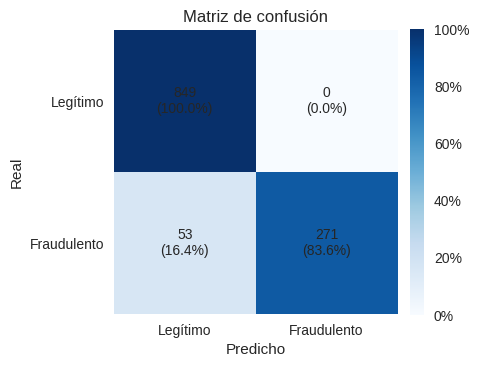

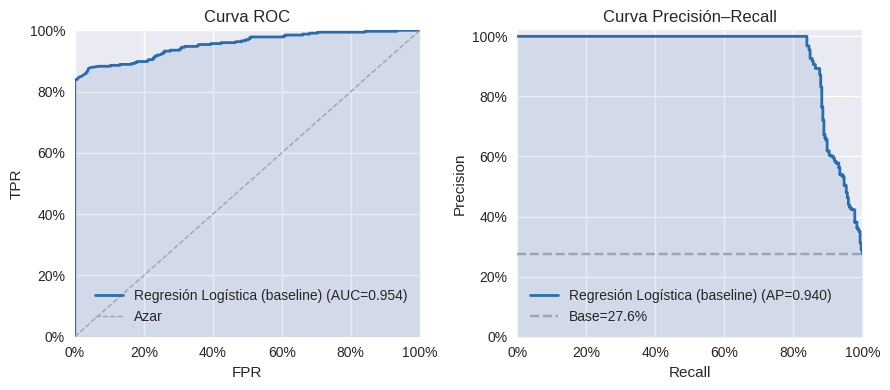

In [ ]:
# Evaluación
evaluar_modelo(y_test, y_prob_lr, model_name="Regresión Logística (baseline)", logger=logger)

El modelo baseline de Regresión Logística muestra métricas generales elevadas, pero presenta un recall de solo 83.6%. Esto significa que, aunque cada predicción positiva es correcta (precisión perfecta), el modelo deja escapar alrededor de 1 de cada 6 sitios phishing reales.
Por lo tanto, aunque sirve como punto de partida, este baseline resulta inadecuado como solución práctica.

<a id='sec-decisiontree'></a>
### 6.2. Árbol de decisión

Para comenzar a probar otros modelos de machine learning, vamos a comenzar con el árbol de decisión simple y ver que resultados nos arroja.

In [ ]:
# ==== Modelo DecisionTree ====
dt_model = DecisionTreeClassifier(random_state=42)

# Entrenamiento
dt_model.fit(X_train, y_train)

# Predicciones
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]   # probabilidades de clase positiva
y_pred_dt = (y_prob_dt >= 0.5).astype(int)         # etiquetas binarias (umbral 0.5)

=== Métricas ===
Accuracy    0.925
Precision   0.878
Recall      0.846
F1          0.862
ROC_AUC     0.921
PR_AUC      0.849


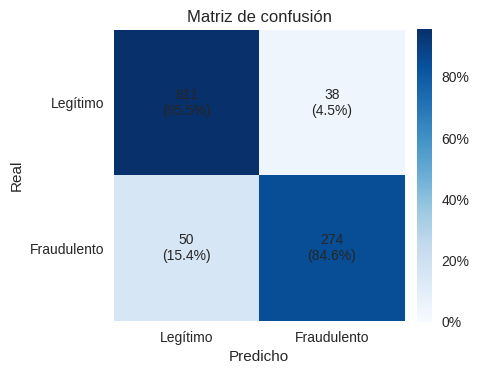

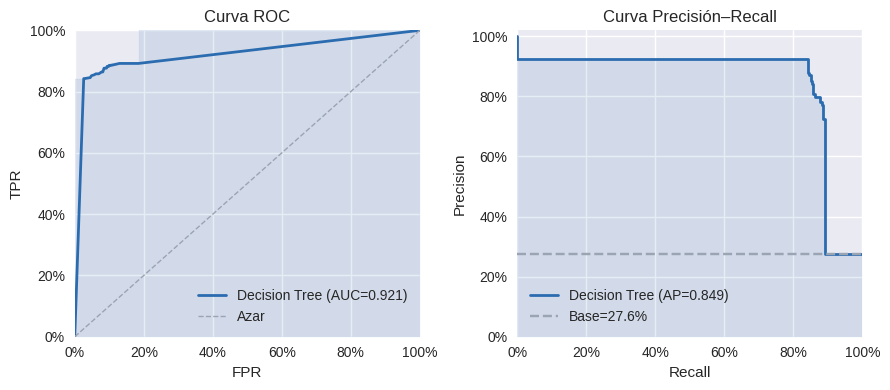

In [ ]:
# Evaluación
evaluar_modelo(y_test, y_prob_dt, model_name="Decision Tree", logger=logger)

Luego de entrenar el árbol, el recall aumentó muy poco, pero la precisión bajo un 13%, por lo que decidimos avanzar con un método mas robusto.

<a id='sec-rf'></a>
### 6.3. Random Forest

El random forest mejora el desempeño de los árboles de decisión individuales, entrenando a varios de ellos y tomando como decisión final para la clasificación, lo que haya votado la mayoría.

In [ ]:
# ==== Modelo RandomForest ====
rf_model = RandomForestClassifier(random_state=42)

# Entrenamiento
rf_model.fit(X_train, y_train)

# Predicciones
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]   # probabilidades de clase positiva
y_pred_rf = (y_prob_rf >= 0.5).astype(int)         # etiquetas binarias (umbral 0.5)

=== Métricas ===
Accuracy    0.945
Precision   0.951
Recall      0.843
F1          0.894
ROC_AUC     0.940
PR_AUC      0.927


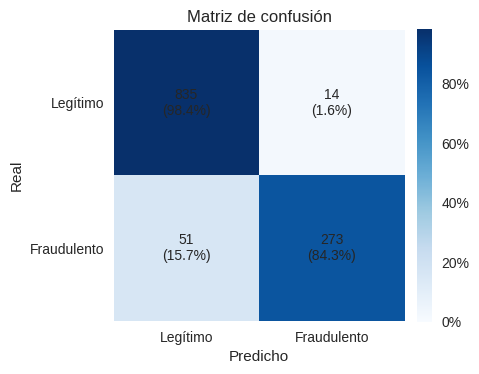

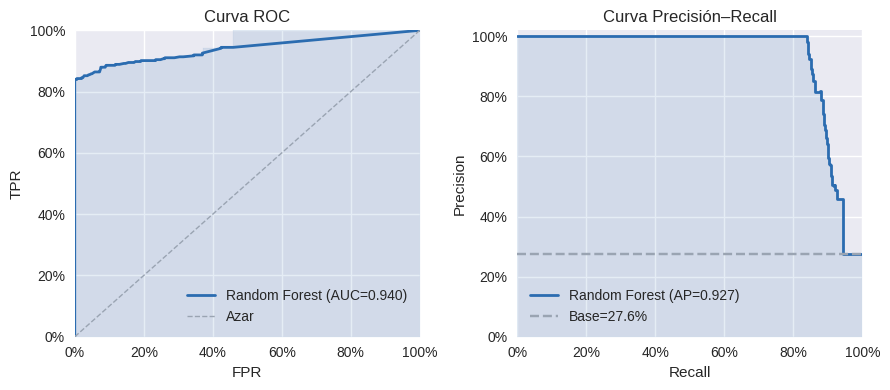

In [ ]:
# Evaluación
evaluar_modelo(y_test, y_prob_rf, model_name="Random Forest", logger=logger)

Luego de entrenar el modelo, vemos que se mantuvo la mejora del recall obtenida anteriormente, pero ahora recuperamos la alta precisión que se había perdido al entrenar solo un árbol. Como resultado vemos que el área bajo la curva de Precisión/Recall es de 0.927, donde 1 es el valor máximo que se puede lograr.

<a id='sec-rf-smote'></a>
### 6.4. Random Forest + SMOTE


A continuación decidimos probar el random forest, pero esta vez utilizando la técnica de SMOTE para balancear las clases y ver si de esta manera logramos mejoras en los resultados finales.

In [ ]:
# ==== RandomForest con SMOTE ====
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

# 1) Oversampling SOLO en el entrenamiento
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# 2) Entrenamiento del modelo en los datos re-muestreados
rf_model_smote = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_model_smote.fit(X_train_smote, y_train_smote)

# 3) Predicciones en TEST (sin SMOTE)
y_prob_rf_smote = rf_model_smote.predict_proba(X_test)[:, 1]
y_pred_rf_smote = (y_prob_rf_smote >= 0.5).astype(int)

=== Métricas ===
Accuracy    0.927
Precision   0.861
Recall      0.877
F1          0.869
ROC_AUC     0.940
PR_AUC      0.930


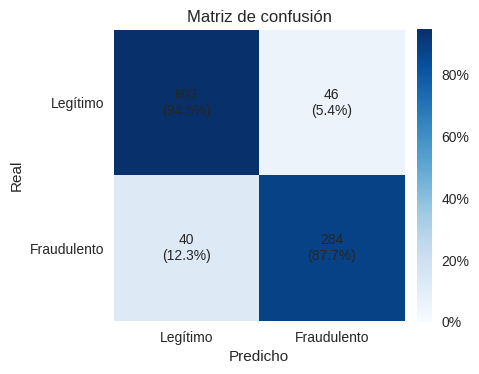

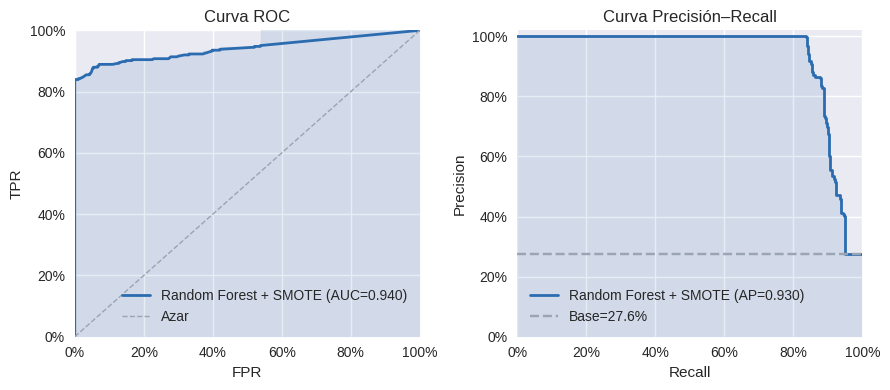

In [ ]:
# Evaluación
evaluar_modelo(y_test, y_prob_rf_smote, model_name="Random Forest + SMOTE", logger=logger)

En este caso vemos que se elevo en buena medida el recall (pasa de 0.843 a 0.877), pero perdimos nuevamente precisión, quedando esta por debajo del recall y en un valor demasiado bajo comparado con los otros modelos.

<a id='sec-xgb'></a>
### 6.5. XGBoost


En esta sección se desarrollamos un modelo de Gradient Boosting (XGBoost). Este enfoque combina múltiples árboles de decisión de manera secuencial, cada uno corrigiendo los errores del anterior. Es uno de los algoritmos más potentes y utilizados en la práctica por su capacidad para manejar datos heterogéneos y capturar relaciones complejas.

A continuación se describe paso a paso el proceso de construcción, entrenamiento, evaluación e interpretación del modelo.

In [ ]:
# ==== Modelo XGBoost (baseline por defecto) ====
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

# Entrenamiento
xgb_model.fit(X_train, y_train)

# Predicciones
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_prob_xgb >= 0.5).astype(int)

=== Métricas ===
Accuracy    0.952
Precision   0.986
Recall      0.840
F1          0.907
ROC_AUC     0.948
PR_AUC      0.937


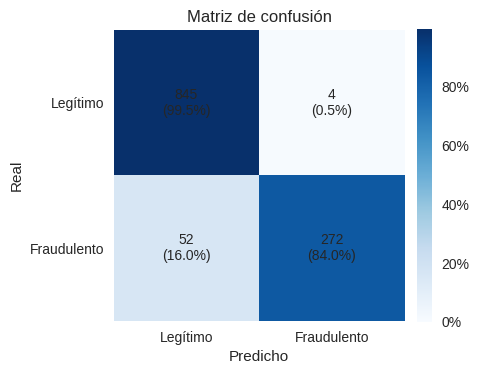

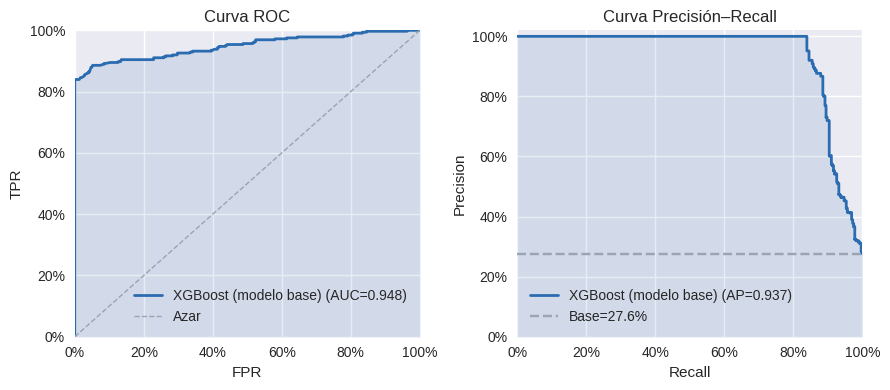

In [ ]:
# Evaluación
evaluar_modelo(y_test, y_prob_xgb, model_name="XGBoost (modelo base)", logger=logger)

<a id='sec-xgb-gs'></a>
### 6.6. XGBoost con ajuste de hiperparámetros (GridSearchCV)

Utilizamos GridSearchCV para XGBoost con el objetivo de ajustar hiperparámetros optimizando PR-AUC. Tras probar distintas combinaciones con validación cruzada, se selecciona el mejor modelo, se reentrena y se evalúa en el conjunto de test
Los hiperparámetros que se ajustan son número de árboles, profundidad máxima, tasa de aprendizaje, etc; buscando encontrar un balance entre sesgo y varianza.

In [ ]:
# ==== GridSearch para XGBoost optimizando PR-AUC ====
import numpy as np
import pickle
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report, average_precision_score

# 1) Modelo base con manejo de desbalance
pos = int((y_train == 1).sum())
neg = int((y_train == 0).sum())
pos_weight = float(neg) / float(max(pos, 1))  # >1 si la clase positiva es minoritaria

xgb_base = XGBClassifier(
    scale_pos_weight=pos_weight,  # peso de clase para desbalance
    eval_metric="auc",            # métrica interna (cv usa 'scoring' abajo)
    tree_method="hist",           # rápido y estable
    max_bin=256,
    missing=np.nan,
    random_state=42,
    n_jobs=-1,
)

# 2) Espacio de búsqueda
param_grid = {
    "n_estimators":     [100, 200, 400],
    "max_depth":        [4, 6, 8],
    "learning_rate":    [0.01, 0.05, 0.1],
    "subsample":        [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

# 3) Validación cruzada estratificada
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 4) GridSearchCV optimizando PR-AUC (average_precision)
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring="average_precision",   # PR-AUC
    cv=cv,
    verbose=2,
    n_jobs=-1,
    refit=True,   # tras la búsqueda, reentrena con los mejores
)

# 5) Entrenar búsqueda en TRAIN
grid_search.fit(X_train, y_train)

print("\n=== Resultados GridSearch ===")
print("Mejores parámetros:", grid_search.best_params_)
print("Mejor PR-AUC (CV):", round(grid_search.best_score_, 6))

# 6) Modelo final: mejor estimador reentrenado
xgb_model_gs = grid_search.best_estimator_

# Reentrenar en TRAIN con evaluación en VALID
xgb_model_gs.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=False,
)

# 7) Evaluación en TEST
y_prob_xgb_gs = xgb_model_gs.predict_proba(X_test)[:, 1]
y_pred_xgb_gs = (y_prob_xgb_gs >= 0.5).astype(int)

Fitting 3 folds for each of 108 candidates, totalling 324 fits

=== Resultados GridSearch ===
Mejores parámetros: {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 400, 'subsample': 0.8}
Mejor PR-AUC (CV): 0.945622


=== Métricas ===
Accuracy    0.951
Precision   0.978
Recall      0.840
F1          0.904
ROC_AUC     0.955
PR_AUC      0.941


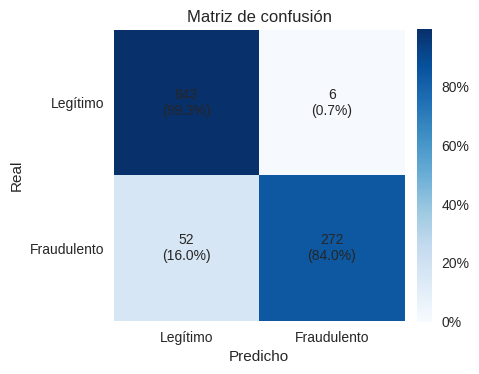

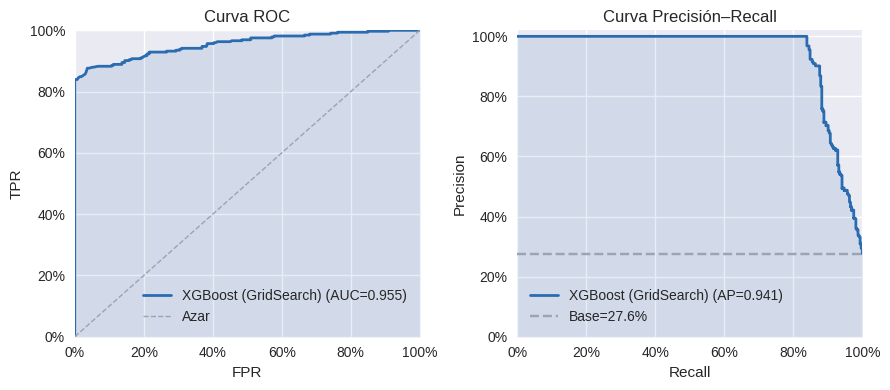

In [ ]:
# Evaluación
evaluar_modelo(y_test, y_prob_xgb_gs, model_name="XGBoost (GridSearch)", logger=logger)

El modelo de XGBoost con ajuste de hiperparámetros y función de peso para el manejo de clases desbalanceadas muestra un rendimiento superior en la detección de phishing, consolidando los hallazgos de los modelos previos.

La matriz de confusión para XGBoost (modelo ajustado) muestra que minimiza los errores en el conjunto de prueba (test).

### Interpretación de features
Se analizan las características más relevantes identificadas por el modelo. Esto permite comprender cómo el algoritmo utiliza la información para realizar predicciones.

/tmp/ipython-input-3607373280.py:14: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample)


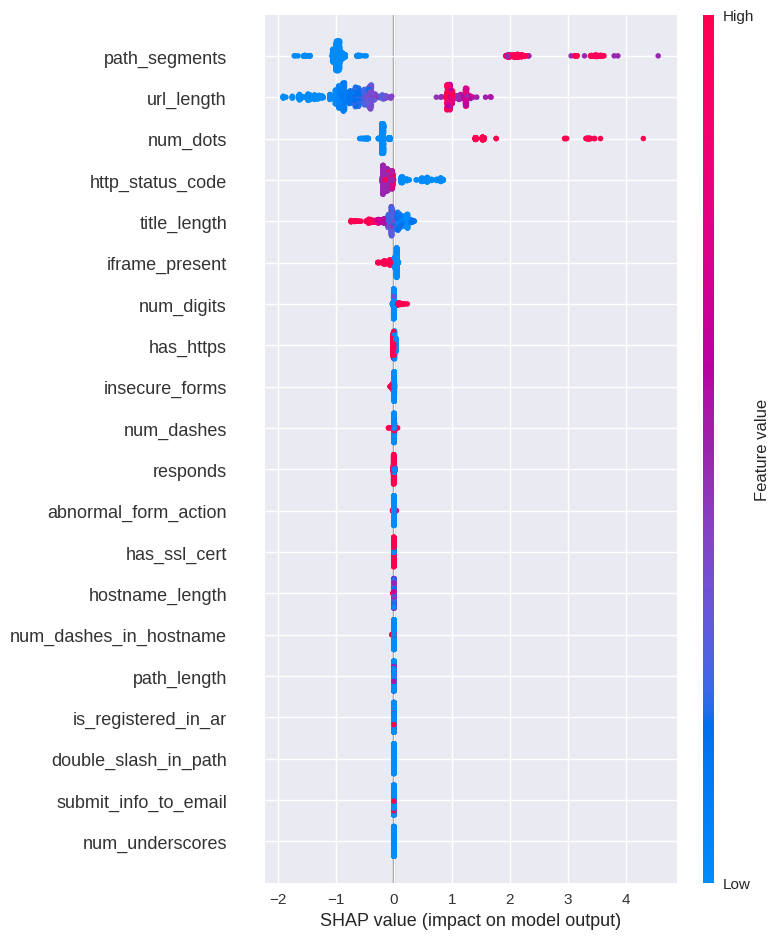

In [ ]:
import shap

# Configuración para visualización interactiva de SHAP
shap.initjs()

# 1. Inicializar el explainer (para modelos tree-based)
explainer = shap.TreeExplainer(xgb_model_gs)

# 2. Calcular valores SHAP (sobre un subset para performance)
X_sample = X_test.sample(1000, random_state=42)
shap_values = explainer.shap_values(X_sample)

# 3. Importancia global
shap.summary_plot(shap_values, X_sample)

# 4. Explicación individual (ej: primer cliente del test)
shap.force_plot(explainer.expected_value, shap_values[0,:], X_sample.iloc[0,:])

### Importancia de variables
Se visualiza la importancia relativa de cada variable en XGBoost. Las variables con mayor importancia contribuyen más a la construcción de los árboles.  
Si una sola feature explica casi todo (ej. responds o http_status_code), entonces existe riesgo de leakage o un proxy del target.

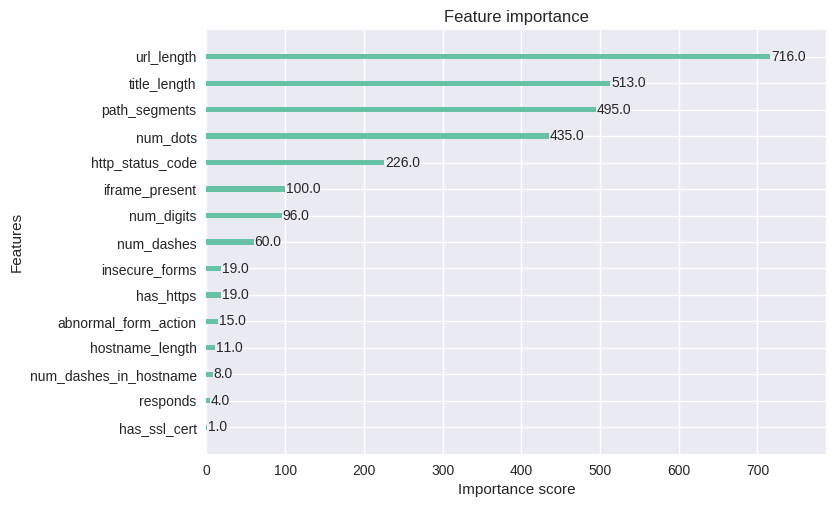

In [ ]:
from xgboost import plot_importance

plot_importance(xgb_model_gs, max_num_features=15)
plt.show()

### Correlación con la variable objetivo
Se calcula la correlación estadística entre las variables independientes y el target. Esto ofrece evidencia adicional para interpretar el rol de cada variable.  
Variables con correlación absoluta > 0.7 son sospechosas.

In [ ]:
corr = df.corr(numeric_only=True)["is_phishing"].sort_values(ascending=False)
print(corr)


is_phishing               1.000000
path_segments             0.733812
is_registered_in_ar       0.619052
path_length               0.571914
abnormal_form_action      0.556903
url_length                0.553567
num_dashes                0.551130
num_dashes_in_hostname    0.515308
query_length              0.499866
num_dots                  0.437790
submit_info_to_email      0.411307
num_special_chars         0.392024
insecure_forms            0.378704
num_digits                0.311299
double_slash_in_path      0.213461
hostname_length           0.196685
num_underscores           0.140131
http_status_code          0.084845
iframe_present           -0.009185
title_length             -0.245016
has_https                -0.323092
has_ssl_cert             -0.325960
responds                 -0.415687
Name: is_phishing, dtype: float64


<a id='sec-comp'></a>
## 7. Comparación de modelos
Consolidamos las métricas de los modelos evaluados en una misma tabla comparativa, lo que nos permite analizar de forma integrada el desempeño de cada algoritmo y facilitar la selección del más adecuado según los objetivos del problema


| Campo       | Descripción                                                                 |
|-------------|------------------------------------------------------------------------------|
| **Model**   | Nombre del modelo evaluado (ej. Regresión Logística, Random Forest).        |
| **Threshold** | Umbral usado para convertir probabilidades en clases (ej. 0.5).           |
| **N**       | Cantidad total de observaciones evaluadas.                                  |
| **Positives** | Número de casos positivos (clase 1) en la muestra.                        |
| **Prevalence** | Proporción de la clase positiva respecto del total.                        |
| **Accuracy** | Proporción de predicciones correctas sobre el total.                       |
| **Precision** | De los predichos como positivos, cuántos fueron realmente positivos.      |
| **Recall**  | De los positivos reales, cuántos fueron detectados por el modelo.           |
| **F1**      | Media armónica entre *precision* y *recall*, equilibra ambos.               |
| **ROC_AUC** | Área bajo la curva ROC; mide la capacidad de distinguir entre clases.       |
| **PR_AUC**  | Área bajo la curva Precisión–Recall..        |
| **Timestamp** | Momento en que se registraron las métricas.                               |


In [ ]:
comparar_modelos(logger, sort_by="Timestamp", ascending=True)

,Model,Threshold,N,Positives,Prevalence,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Timestamp
0,Regresión Logística (baseline),0.5,1173,324,0.276215,0.954817,1.000000,0.836420,0.910924,0.954209,0.939696,2025-09-22 20:20:32
1,Decision Tree,0.5,1173,324,0.276215,0.924979,0.878205,0.845679,0.861635,0.921251,0.849429,2025-09-22 20:20:33
2,Random Forest,0.5,1173,324,0.276215,0.944587,0.951220,0.842593,0.893617,0.939540,0.926904,2025-09-22 20:20:34
3,Random Forest + SMOTE,0.5,1173,324,0.276215,0.926684,0.860606,0.876543,0.868502,0.940095,0.930053,2025-09-22 20:20:36
4,XGBoost (modelo base),0.5,1173,324,0.276215,0.952259,0.985507,0.839506,0.906667,0.947891,0.937338,2025-09-22 20:20:38
5,XGBoost (GridSearch),0.5,1173,324,0.276215,0.950554,0.978417,0.839506,0.903654,0.955107,0.941357,2025-09-22 20:21:44


<a id='sec-conclusiones'></a>
## 8. Conclusiones

Al comparar el desempeño de los modelos evaluados, XGBoost se posiciona como la alternativa más robusta y confiable. A diferencia de la regresión logística, la cual mostró una precisión perfecta y gran simplicidad, presenta la desventaja de un recall limitado al dejar escapar una parte de los sitios phishing.

El modelo XGBoost logró un mejor equilibrio entre precisión y recall, alcanzando métricas estables y competitivas en todas las evaluaciones. Por ello, se considera el modelo más adecuado para un escenario real de detección de phishing, mientras que la regresión logística se mantiene como baseline de referencia.

<a id='sec-prox'></a>
## 9. Próximos pasos

Para complementar el análisis supervisado, el siguiente paso será implementar un modelo de Aprendizaje No Supervisado. Utilizaremos un algoritmo de Clustering para agrupar los sitios web en diferentes perfiles sin necesidad de etiquetas previas de "phishing" o "legítimo". Este enfoque nos permitirá:

- Identificar Patrones: Descubrir nuevas agrupaciones de sitios web con características similares (URL, dominio, etc.) que podrían representar nuevos tipos de ataques o patrones de comportamiento no evidentes en la clasificación supervisada.

- Perfilado: Crear perfiles de riesgo basados en los clusters generados, lo que podría ayudar a un sistema de seguridad a priorizar la revisión de ciertos tipos de sitios web.

Aclarado finalmente y no menos importante, que el input para este modelo de clustering será aquellos sitios etiquetados como "alta probabilidad de fraude" por el modelo de clasificación que obtuvo mejor desempeño en este entregable.